## Load necessary library files

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch import from_numpy as tnsr
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

## Used autoregressive model with order K

$\hat{X}(t) = A_1 X(t-1) + A_2 X(t-2) + \cdots + A_k X(t-k)$

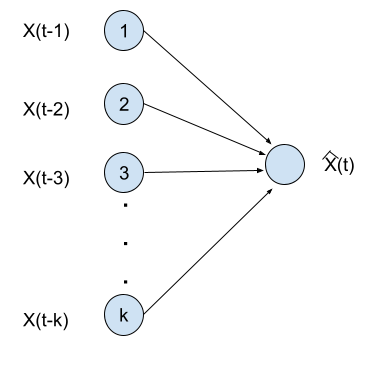

## Define the naive 1 layer auto-regresssive network

In [2]:
tokens = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

class AR(torch.nn.Module):
    def __init__(self, window):
        super(AR, self).__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(window*len(tokens), len(tokens))
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.layer1(x)

        x = torch.nn.functional.softmax(x, dim=1)

        return x

## Define dataset with one hot encoding

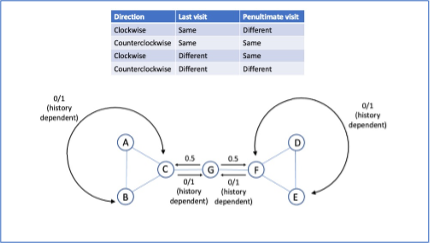

In [3]:
class Dataset_converter(Dataset):
    def __init__(self, data, window=2):
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((len(data)-window, window, len(tokens)))
        self.y = np.zeros((len(data)-window, len(tokens)))

        for ii in range(len(data)-window):
            self.X[ii] = one_hot_encoded[ii:ii+window,:]
            self.y[ii] = one_hot_encoded[ii+window,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

## Load dataset

In [4]:
data = pd.read_csv("Seq_test.txt")['seq'][0]
train_sample_size = 200
train_seq = data[:train_sample_size]
test_seq = data[train_sample_size:]

## Perform the experiment with varying window size (each repeated 10 times)

In [5]:
reps = 10
window_sizes = [1, 2, 4, 6, 8, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
lr = 1e-1
epochs = 100

train_acc = np.zeros((len(window_sizes), reps), dtype=float)
test_acc = np.zeros((len(window_sizes), reps), dtype=float)

for ii, window in enumerate(window_sizes):
    print('Doing window ', window)
    
    test_set = Dataset_converter(test_seq, window)
    train_set = Dataset_converter(train_seq, window)
    
    for rep in tqdm(range(reps)):
        model = AR(window)
        train_loader = DataLoader(train_set, batch_size=1, shuffle=False) 
        
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        criterion = torch.nn.MSELoss()
        
        for epoch in range(epochs):
            for X, y in train_loader:
                optimizer.zero_grad()
                predicted_y = model(X)
                loss = criterion(predicted_y, y)
                loss.backward()
                optimizer.step()
                        
            #print(f'Epoch : {epoch+1}, loss: {loss:.4f}')

        total = 0
        for x, y in train_set:
            predicted_label = model(x.view(1,window,len(tokens)))

            if y.argmax() != 6:
                total += 1
                if y.argmax() == predicted_label.argmax():
                    train_acc[ii,rep] += 1

        train_acc[ii,rep] /= total

        for x, y in test_set:
            predicted_label = model(x.view(1,window,len(tokens)))

            if y.argmax() == predicted_label.argmax():
                test_acc[ii,rep] += 1

        test_acc[ii,rep] /= len(test_set)
            

Doing window  1


100%|██████████| 10/10 [00:24<00:00,  2.50s/it]


Doing window  2


100%|██████████| 10/10 [00:23<00:00,  2.35s/it]


Doing window  4


...

100%|██████████| 10/10 [00:20<00:00,  2.09s/it]


Doing window  28


100%|██████████| 10/10 [00:20<00:00,  2.05s/it]


Doing window  30


100%|██████████| 10/10 [00:20<00:00,  2.02s/it]


## Plot the result

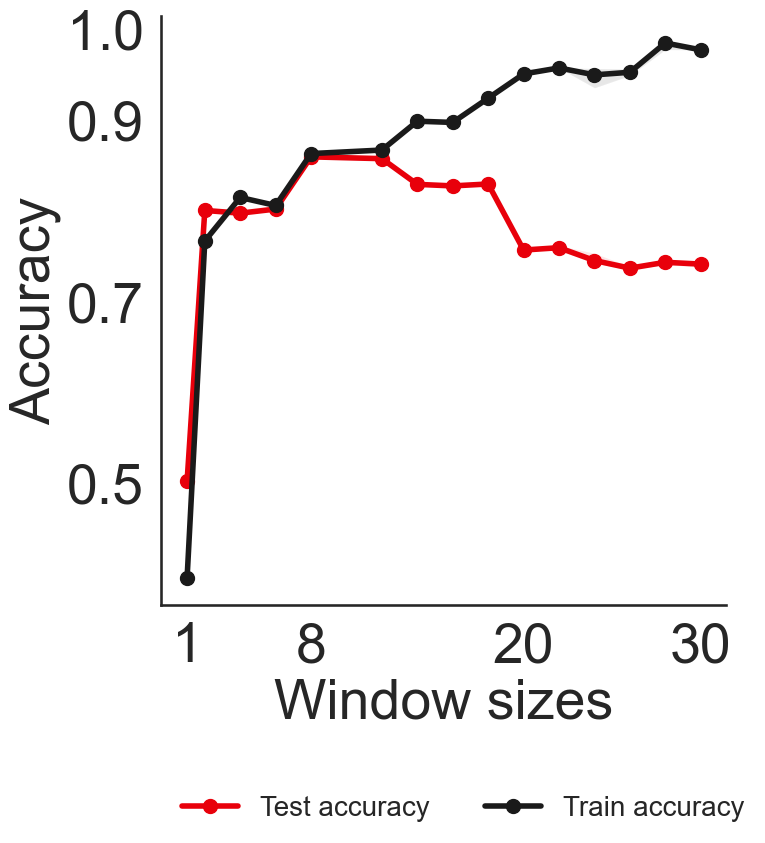

In [6]:
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40

fig, ax = plt.subplots(1, 1, figsize=(8,8))
    
ax.plot(window_sizes, np.median(test_acc,axis=1), 'o-', markersize=10, linewidth=4, c='r', label='Test accuracy')    
ax.fill_between(window_sizes, np.quantile(test_acc, 0.25, axis=1), np.quantile(test_acc, 0.75, axis=1), facecolor='r', alpha=.1)

ax.plot(window_sizes, np.median(train_acc,axis=1), 'o-', markersize=10, linewidth=4, c='k', label='Train accuracy')    
ax.fill_between(window_sizes, np.quantile(train_acc, 0.25, axis=1), np.quantile(train_acc, 0.75, axis=1), facecolor='k', alpha=.1)

ax.tick_params(labelsize=40)
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

ax.set_xticks([1, 8, 20, 30])
ax.set_yticks([0.5, 0.7, 0.9, 1.0])
ax.set_xlabel('Window sizes', fontsize=font)
ax.set_ylabel('Accuracy', fontsize=font)

leg = fig.legend(bbox_to_anchor=(1, -0.001), bbox_transform=plt.gcf().transFigure,
                        ncol=3, fontsize=20, frameon=False)

plt.tight_layout()


## Todos

1. change evaluation protocal, add a dashed line (Bayes optimal)
2. add simple RNNs (gradient clipping) to the plot
3. go as long as 50000, do not repeat